<a href="https://colab.research.google.com/github/sudeeraattanayake/Machine-Learning/blob/main/Multi_Class_Classification_With_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [78]:
df = pd.read_csv('/content/animal_dataset.csv')

In [79]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [80]:
print(X)

    Weight  Height
0       18      74
1        7      20
2       26      66
3        6      28
4        6      33
..     ...     ...
95       3      30
96      25      79
97       1      21
98      26      72
99       6      32

[100 rows x 2 columns]


In [81]:
print(y)

0      Dog
1      Cat
2      Dog
3      Cat
4      Cat
      ... 
95     Cat
96     Dog
97    Bird
98     Dog
99     Cat
Name: Animal, Length: 100, dtype: object


In [82]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

In [83]:
print(X_train)

    Weight  Height
15       3      19
40       4      28
96      25      79
9        3      13
72       3      27
..     ...     ...
60       3      31
71       4      29
14      26      46
92      25      73
51       1      14

[75 rows x 2 columns]


In [84]:
print(X_test)

    Weight  Height
83       2      18
53       6      21
70      29      70
45       2      24
44       1      21
39       3      20
22       2      13
80       6      26
10       3      23
0       18      74
18       1      10
30       2      25
73       7      27
33       2      11
90      24      50
4        6      33
76      19      70
77       3      21
12      19      58
31       7      21
55      23      59
88       1      12
26       7      34
42       1      13
69      15      71


In [85]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 42)
classifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [86]:
y_pred = classifier.predict(X_test)

In [87]:
print(y_pred)

['Bird' 'Cat' 'Dog' 'Bird' 'Bird' 'Bird' 'Bird' 'Cat' 'Cat' 'Dog' 'Bird'
 'Bird' 'Cat' 'Bird' 'Dog' 'Cat' 'Dog' 'Bird' 'Dog' 'Cat' 'Dog' 'Bird'
 'Cat' 'Bird' 'Dog']


In [88]:
from sklearn.metrics import accuracy_score
print("Accuarcy: ",  accuracy_score(y_test, y_pred))

Accuarcy:  0.96


In [89]:
pedction = classifier.predict([[18, 55]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [90]:
print(pedction)

['Dog']


In [91]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

        Bird       1.00      0.92      0.96        12
         Cat       0.86      1.00      0.92         6
         Dog       1.00      1.00      1.00         7

    accuracy                           0.96        25
   macro avg       0.95      0.97      0.96        25
weighted avg       0.97      0.96      0.96        25



In [92]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred, average='weighted'))
print("Recall: ", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score: ", f1_score(y_test, y_pred, average='weighted'))

Accuracy:  0.96
Precision:  0.9657142857142857
Recall:  0.96
F1 Score:  0.9606688963210703


In [93]:
from sklearn.model_selection import cross_val_score

# Assuming 'classifier' (DecisionTreeClassifier) and 'X', 'y' are already defined
# We'll use 5-fold cross-validation
scores = cross_val_score(classifier, X, y, cv=5)

print("Cross-validation scores (accuracy for each fold):", scores)
print("Mean cross-validation accuracy: %0.2f (+/- %0.2f)" % (scores.mean(), scores.std() * 2))

Cross-validation scores (accuracy for each fold): [0.9 1.  0.9 1.  1. ]
Mean cross-validation accuracy: 0.96 (+/- 0.10)


The cross-validation scores show the accuracy of the model on different folds of the data. If the scores are consistently high and close to 1.0, it suggests the model generalizes well. A large standard deviation would indicate variability in performance, which could be a sign of instability or mild overfitting on certain data splits.

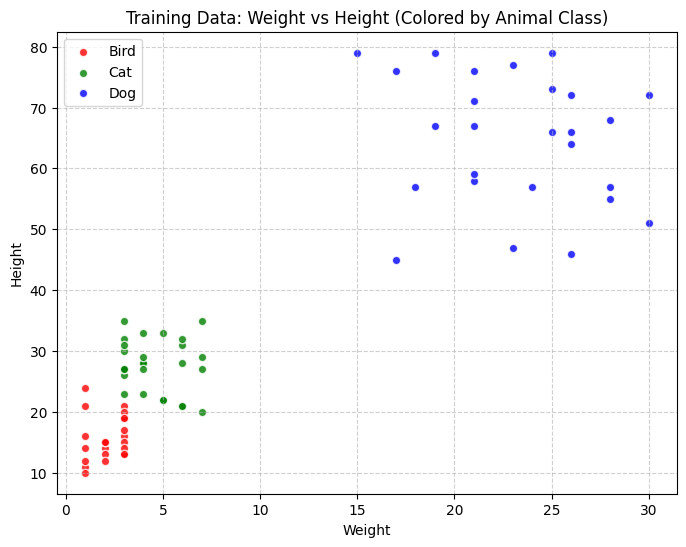

In [94]:
unique_classes = y_train.unique()
colors = ['red', 'green', 'blue', 'purple', 'orange', 'cyan'] # Extend if more classes

plt.figure(figsize=(8, 6))

for i, class_label in enumerate(unique_classes):
    # Filter X_train and y_train for the current class
    X_class = X_train[y_train == class_label]
    y_class = y_train[y_train == class_label]

    # Plot 'Weight' vs 'Height' for the current class
    plt.scatter(X_class['Weight'], X_class['Height'],
                color = colors[i % len(colors)],
                label = class_label,
                alpha=0.8, edgecolors='w')

plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Training Data: Weight vs Height (Colored by Animal Class)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

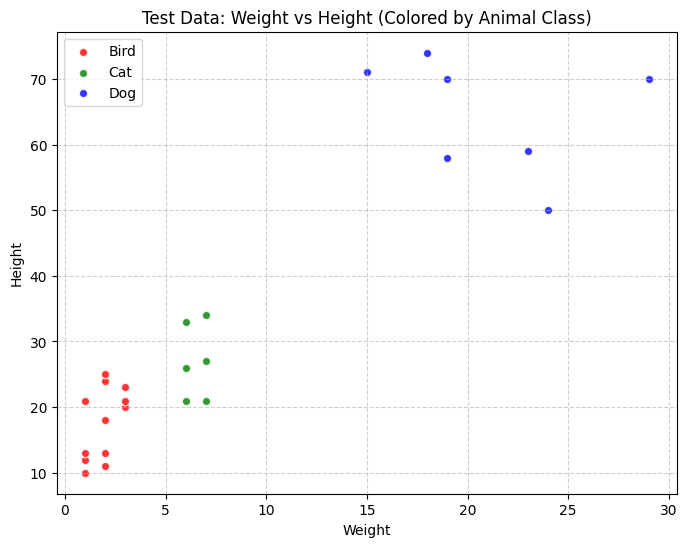

In [95]:
unique_classes_test = y_test.unique()
colors = ['red', 'green', 'blue', 'purple', 'orange', 'cyan']

plt.figure(figsize=(8, 6))

for i, class_label in enumerate(unique_classes_test):
    # Filter X_test and y_test for the current class
    X_class_test = X_test[y_test == class_label]
    y_class_test = y_test[y_test == class_label]

    # Plot 'Weight' vs 'Height' for the current class
    plt.scatter(X_class_test['Weight'], X_class_test['Height'],
                color = colors[i % len(colors)],
                label = class_label,
                alpha=0.8, edgecolors='w')

plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Test Data: Weight vs Height (Colored by Animal Class)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()